# 6주차 실습: 효율적인 신경망 학습을 위한 최적화 기법 이해

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


In [2]:
def plot_curves(curves, title="curve", xlabel="epoch", ylabel="loss"):
    plt.figure(figsize=(6, 4))
    for name, values in curves.items():
        plt.plot(values, label=name)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

def binary_accuracy_from_logits(logits, y):
    pred = (torch.sigmoid(logits) > 0.5).float()
    return (pred == y).float().mean().item()

## 1. 데이터 생성

In [3]:
def make_harder_mlp_data(
    n_samples=2000,
    noise=0.25,
    train_ratio=0.15,
    val_ratio=0.35,
    n_noise_features=50,
    spurious_strength=3.0,
    train_spurious_corr = 0.8,
    test_spurious_corr = 0.8,
    random_state=42
):
    np.random.seed(random_state)

    X2, y = make_moons(n_samples=n_samples, noise=noise, random_state=random_state)
    y = y.astype(np.float32)

    X_train, X_temp, y_train, y_temp = train_test_split(
        X2, y, test_size=(1 - train_ratio), stratify=y, random_state=random_state
    )

    val_portion = val_ratio / (1 - train_ratio)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=(1 - val_portion),
        stratify=y_temp, random_state=random_state
    )

    def add_noise_features(X, n_noise):
        noise_feat = np.random.randn(len(X), n_noise)
        return np.concatenate([X, noise_feat], axis=1)

    X_train = add_noise_features(X_train, n_noise_features)
    X_val   = add_noise_features(X_val, n_noise_features)
    X_test  = add_noise_features(X_test, n_noise_features)

    def make_spurious_feature(y, corr, strength):
        aligned = y.copy()
        flip_mask = np.random.rand(len(y)) > corr
        aligned[flip_mask] = 1 - aligned[flip_mask]
        spurious = (2 * aligned - 1) * strength + np.random.randn(len(y)) * 0.5
        return spurious.reshape(-1, 1)

    s_train = make_spurious_feature(y_train, train_spurious_corr, spurious_strength)
    s_val   = make_spurious_feature(y_val, test_spurious_corr, spurious_strength)
    s_test  = make_spurious_feature(y_test, test_spurious_corr, spurious_strength)

    X_train = np.concatenate([X_train, s_train], axis=1)
    X_val   = np.concatenate([X_val, s_val], axis=1)
    X_test  = np.concatenate([X_test, s_test], axis=1)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val   = scaler.transform(X_val)
    X_test  = scaler.transform(X_test)

    return (
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32).view(-1, 1),
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.float32).view(-1, 1),
        torch.tensor(X_test, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.float32).view(-1, 1),
    )

In [4]:
X_train, y_train, X_val, y_val, X_test, y_test = make_harder_mlp_data(
    n_samples=2000,
    noise=0.25,
    train_ratio=0.6,
    val_ratio=0.2,
    n_noise_features=10,
    spurious_strength=3.0,
    train_spurious_corr=0.80,
    test_spurious_corr=0.80,
    random_state=42
)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape,   "y_val  :", y_val.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)

train_dataset = TensorDataset(X_train, y_train)
val_dataset   = TensorDataset(X_val, y_val)
test_dataset  = TensorDataset(X_test, y_test)

X_train: torch.Size([1200, 13]) y_train: torch.Size([1200, 1])
X_val  : torch.Size([400, 13]) y_val  : torch.Size([400, 1])
X_test : torch.Size([400, 13]) y_test : torch.Size([400, 1])


In [5]:
for bs in [1, 16, 64, len(train_dataset)]:
    loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    print(f"batch_size={bs:4d} | iterations_per_epoch={len(loader)}")

batch_size=   1 | iterations_per_epoch=1200
batch_size=  16 | iterations_per_epoch=75
batch_size=  64 | iterations_per_epoch=19
batch_size=1200 | iterations_per_epoch=1


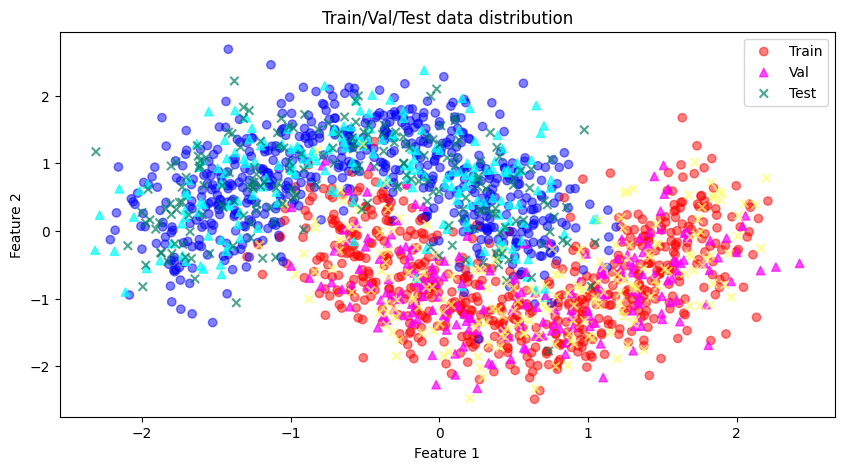

In [6]:
# 데이터 plot 완성
plt.figure(figsize=(10, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train.squeeze().numpy(), cmap='bwr', alpha=0.5, label='Train')
plt.scatter(X_val[:, 0], X_val[:, 1], c=y_val.squeeze().numpy(), cmap='cool', marker='^', alpha=0.7, label='Val')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test.squeeze().numpy(), cmap='summer', marker='x', alpha=0.7, label='Test')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Train/Val/Test data distribution')
plt.legend()
plt.show()

## 2. 모델 정의

In [7]:
class BasicMLP(nn.Module):  # 기본 (ReLU, Dropout층 추가)
    def __init__(self, input_dim, hidden_dims=[128, 64], dropout=0.0):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class InitMLP(nn.Module):   # Relu, initialized,
    def __init__(self, input_dim, hidden_dims=[128, 64], dropout=0.0, init_mode="default"):
        super().__init__()
        layers = []
        prev_dim = input_dim
        self.linears = []
        self.init_mode = init_mode

        for h in hidden_dims:
            fc = nn.Linear(prev_dim, h)
            self.linears.append(fc)
            layers.append(fc)
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_dim = h

        out_fc = nn.Linear(prev_dim, 1)
        self.linears.append(out_fc)
        layers.append(out_fc)
        self.net = nn.Sequential(*layers)
        self.apply_init()

    def apply_init(self):
        for layer in self.linears:
            if self.init_mode == "small":
                nn.init.normal_(layer.weight, mean=0.0, std=0.01)
            elif self.init_mode == "xavier":
                nn.init.xavier_normal_(layer.weight)
            elif self.init_mode == "he":
                nn.init.kaiming_normal_(layer.weight, nonlinearity="relu")
            elif self.init_mode == "default":
                pass
            else:
                raise ValueError(f"Unknown init_mode: {self.init_mode}")
            nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)


class NormMLP(nn.Module):  # BN, LN 비교
    def __init__(self, input_dim, hidden_dims=[128, 64], norm_type=None, dropout=0.0):
        super().__init__()
        layers = []
        prev_dim = input_dim

        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            if norm_type == "bn":
                layers.append(nn.BatchNorm1d(h))
            elif norm_type == "ln":
                layers.append(nn.LayerNorm(h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_dim = h

        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

## 3. 학습 / 평가 함수

In [8]:
def evaluate_model(model, loader, criterion):  # loader: data loader
    model.eval()  # eval, train 차이: BN이 들어감
    total_loss = 0.0
    total_acc = 0.0
    total_n = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)
            acc = binary_accuracy_from_logits(logits, yb)

            bs = xb.size(0)
            total_loss += loss.item() * bs
            total_acc += acc * bs
            total_n += bs

    return total_loss / total_n, total_acc / total_n

In [9]:
def train_model(
    model_fn,
    optimizer_name="sgd",
    batch_size=32,
    lr=1e-2,
    epochs=80,
    weight_decay=0.0,
    train_dataset=None,
    val_dataset=None,
    test_dataset=None,
):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)  # 일반화 성능 업
    val_loader   = DataLoader(val_dataset, batch_size=256, shuffle=False)
    test_loader  = DataLoader(test_dataset, batch_size=256, shuffle=False)

    model = model_fn().to(device)
    criterion = nn.BCEWithLogitsLoss()

    if optimizer_name == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "momentum":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    elif optimizer_name == "nesterov":
        optimizer = optim.SGD(
            model.parameters(), lr=lr, momentum=0.9, nesterov=True, weight_decay=weight_decay)
    elif optimizer_name == "adagrad":
        optimizer = optim.Adagrad(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "rmsprop":
        optimizer = optim.RMSprop(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_acc": [],
        "test_loss": [], "test_acc": [],
    }

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        total_acc = 0.0
        total_n = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            bs = xb.size(0)
            total_loss += loss.item() * bs
            total_acc += binary_accuracy_from_logits(logits, yb) * bs
            total_n += bs

        history["train_loss"].append(total_loss / total_n)
        history["train_acc"].append(total_acc / total_n)

        val_loss, val_acc = evaluate_model(model, val_loader, criterion)
        test_loss, test_acc = evaluate_model(model, test_loader, criterion)

        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

    return model, history

## 4. Optimizer 비교 실험

In [10]:
optimizer_results = {}

optimizer_settings = {
    "SGD":      {"optimizer_name": "sgd",      "lr": 0.003},
    "Momentum": {"optimizer_name": "momentum", "lr": 0.003},
    "RMSProp":  {"optimizer_name": "rmsprop",  "lr": 0.003},
    "Adam":     {"optimizer_name": "adam",     "lr": 0.003},
}

for name, cfg in optimizer_settings.items():
    model_fn = lambda: BasicMLP(
        input_dim=X_train.shape[1],
        hidden_dims=[128, 64],
        dropout=0.0
    )
    _, hist = train_model(
        model_fn=model_fn,
        optimizer_name=cfg["optimizer_name"],
        batch_size=32,
        lr=cfg["lr"],
        epochs=80,
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        test_dataset=test_dataset,
    )
    optimizer_results[name] = hist

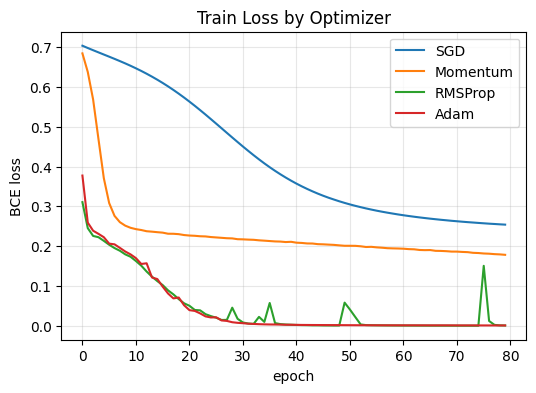

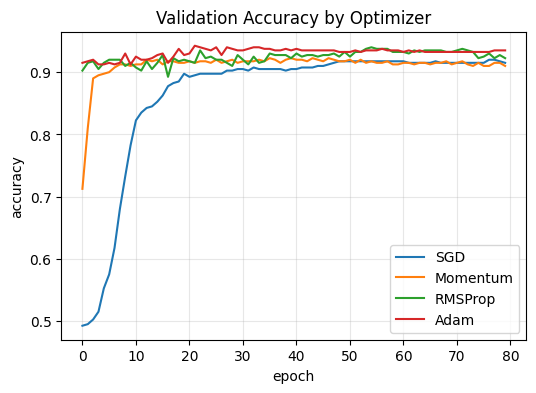

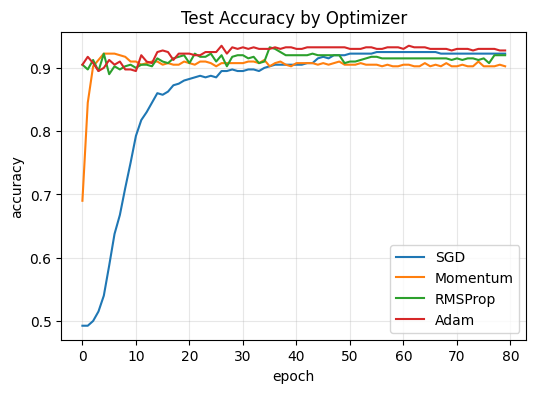

In [11]:
plot_curves(
    {name: hist["train_loss"] for name, hist in optimizer_results.items()},
    title="Train Loss by Optimizer", xlabel="epoch", ylabel="BCE loss"
)
plot_curves(
    {name: hist["val_acc"] for name, hist in optimizer_results.items()},
    title="Validation Accuracy by Optimizer", xlabel="epoch", ylabel="accuracy"
)
plot_curves(
    {name: hist["test_acc"] for name, hist in optimizer_results.items()},
    title="Test Accuracy by Optimizer", xlabel="epoch", ylabel="accuracy"
)

## 5. Batch size 비교 실험

In [12]:
batch_results = {}

for bs in [1, 16, 64, len(train_dataset)]:
    model_fn = lambda: BasicMLP(
        input_dim=X_train.shape[1],
        hidden_dims=[128, 64],
        dropout=0.0
    )
    _, hist = train_model(
        model_fn=model_fn,
        optimizer_name="momentum",
        batch_size=bs,
        lr=0.003,
        epochs=80,
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        test_dataset=test_dataset,
    )
    batch_results[f"bs={bs}"] = hist

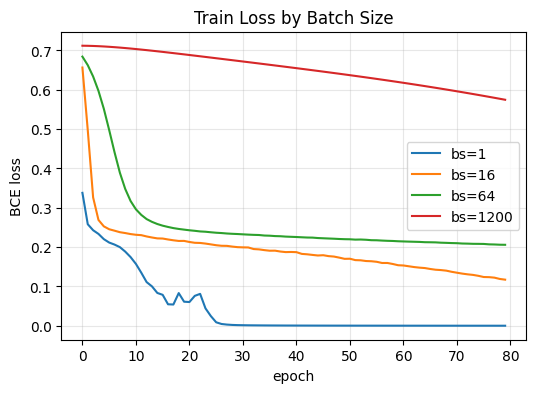

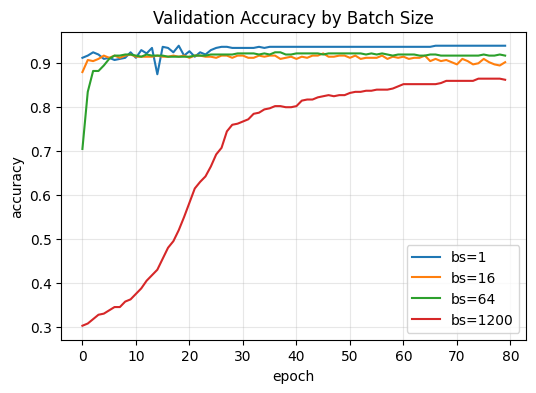

In [13]:
plot_curves(
    {name: hist["train_loss"] for name, hist in batch_results.items()},
    title="Train Loss by Batch Size", xlabel="epoch", ylabel="BCE loss"
)
plot_curves(
    {name: hist["val_acc"] for name, hist in batch_results.items()},
    title="Validation Accuracy by Batch Size", xlabel="epoch", ylabel="accuracy"
)

## 6. Initialization 비교 실험

In [14]:
init_results = {}

for init_mode in ["small", "xavier", "he"]:  # small: 균등 // xavier: 1/root(n/1) > sigmoid, tanh // he: 2/root(n/1) > relu
    model_fn = lambda init_mode=init_mode: InitMLP(
        input_dim=X_train.shape[1],
        hidden_dims=[128, 64],
        dropout=0.0,
        init_mode=init_mode
    )
    _, hist = train_model(
        model_fn=model_fn,
        optimizer_name="adam",
        batch_size=32,
        lr=0.003,
        epochs=80,
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        test_dataset=test_dataset,
    )
    init_results[init_mode] = hist

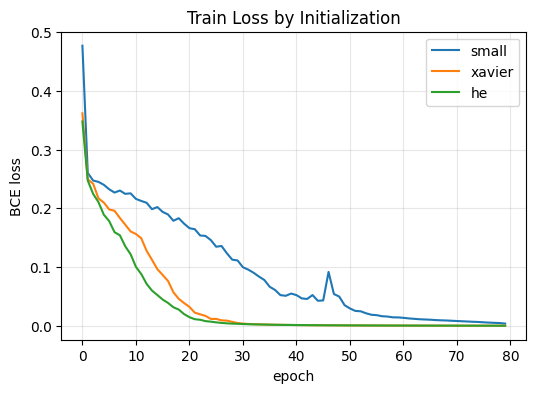

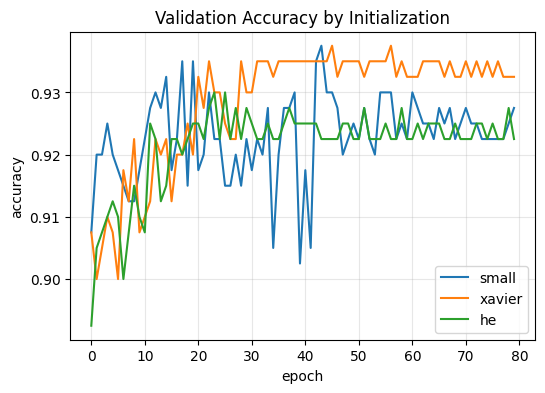

In [15]:
plot_curves(
    {name: hist["train_loss"] for name, hist in init_results.items()},
    title="Train Loss by Initialization", xlabel="epoch", ylabel="BCE loss"
)
plot_curves(
    {name: hist["val_acc"] for name, hist in init_results.items()},
    title="Validation Accuracy by Initialization", xlabel="epoch", ylabel="accuracy"
)

## 7. BN / LN 비교 실험

In [16]:
norm_results = {}

for norm_type in [None, "bn", "ln"]:
    name = "NoNorm" if norm_type is None else norm_type.upper()

    model_fn = lambda norm_type=norm_type: NormMLP(
        input_dim=X_train.shape[1],
        hidden_dims=[128, 64],
        norm_type=norm_type,
        dropout=0.0
    )
    _, hist = train_model(
        model_fn=model_fn,
        optimizer_name="adam",
        batch_size=256,
        lr=0.003,
        epochs=80,
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        test_dataset=test_dataset,
    )
    norm_results[name] = hist

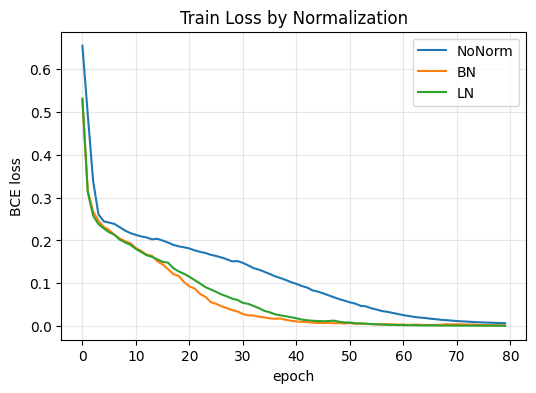

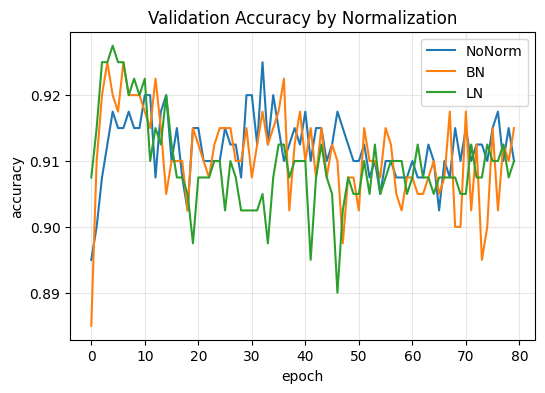

In [17]:
plot_curves(
    {name: hist["train_loss"] for name, hist in norm_results.items()},
    title="Train Loss by Normalization", xlabel="epoch", ylabel="BCE loss"
)
plot_curves(
    {name: hist["val_acc"] for name, hist in norm_results.items()},
    title="Validation Accuracy by Normalization", xlabel="epoch", ylabel="accuracy"
)

In [18]:
import torch
import torch.nn as nn

# [Batch Size, Feature Dimension]
# 예: 3개의 데이터 샘플, 각 샘플은 4개의 특징값을 가짐
sample_input = torch.randn(3, 4)

print("--- Input Data (3 samples, 4 features) ---")
print(sample_input)
print("\n")

# 1. Batch Normalization (BN)
# 각 'Feature' 별로 세로 방향(Batch) 통계량을 구함
bn = nn.BatchNorm1d(num_features=4)
bn_out = bn(sample_input)

# 2. Layer Normalization (LN)
# 각 'Sample' 별로 가로 방향(Feature) 통계량을 구함
ln = nn.LayerNorm(normalized_shape=4)
ln_out = ln(sample_input)

# --- 검증: BN은 세로(Column) 평균이 0인가? ---
print("BN: Mean across Batch (dim=0):")
print(bn_out.mean(dim=0).detach().numpy().round(4))

# --- 검증: LN은 가로(Row) 평균이 0인가? ---
print("LN: Mean across Features (dim=1):")
print(ln_out.mean(dim=1).detach().numpy().round(4))

# --- 확인: BN 결과 ---
print("\n--- BN Output ---")
print(bn_out)

# --- 확인: LN 결과 ---
print("\n--- LN Output ---")
print(ln_out)

# --- 확인: BN 파라미터 ---
print("\n--- BN Parameters ---")
print(list(bn.parameters()))

# -- 확인: LN 파라미터 ---
print("\n--- LN Parameters ---")
print(list(ln.parameters()))

--- Input Data (3 samples, 4 features) ---
tensor([[-1.1037, -0.1395,  2.4874, -0.2397],
        [-0.6135,  0.5189, -0.7737, -0.4109],
        [ 1.0551, -0.0925,  0.7585, -0.3656]])


BN: Mean across Batch (dim=0):
[-0.  0.  0. -0.]
LN: Mean across Features (dim=1):
[-0.  0.  0.]

--- BN Output ---
tensor([[-0.9555, -0.7840,  1.2486,  1.3661],
        [-0.4251,  1.4112, -1.1994, -0.9951],
        [ 1.3806, -0.6272, -0.0492, -0.3710]],
       grad_fn=<NativeBatchNormBackward0>)

--- LN Output ---
tensor([[-1.0077, -0.2906,  1.6634, -0.3651],
        [-0.5863,  1.6740, -0.9059, -0.1818],
        [ 1.2232, -0.7367,  0.7166, -1.2031]],
       grad_fn=<NativeLayerNormBackward0>)

--- BN Parameters ---
[Parameter containing:
tensor([1., 1., 1., 1.], requires_grad=True), Parameter containing:
tensor([0., 0., 0., 0.], requires_grad=True)]

--- LN Parameters ---
[Parameter containing:
tensor([1., 1., 1., 1.], requires_grad=True), Parameter containing:
tensor([0., 0., 0., 0.], requires_grad=True

## 8. 작은 batch size에서 BN / LN 비교

In [19]:
small_batch_norm_results = {}

for bs in [2, 8, 256]:
    for norm_type in [None, "bn", "ln"]:
        name = "NoNorm" if norm_type is None else norm_type.upper()

        model_fn = lambda norm_type=norm_type: NormMLP(
            input_dim=X_train.shape[1],
            hidden_dims=[128, 64],
            norm_type=norm_type,
            dropout=0.0
        )
        _, hist = train_model(
            model_fn=model_fn,
            optimizer_name="adam",
            batch_size=bs,
            lr=0.003,
            epochs=80,
            train_dataset=train_dataset,
            val_dataset=val_dataset,
            test_dataset=test_dataset,
        )

        small_batch_norm_results[f"{name}-bs{bs}"] = hist

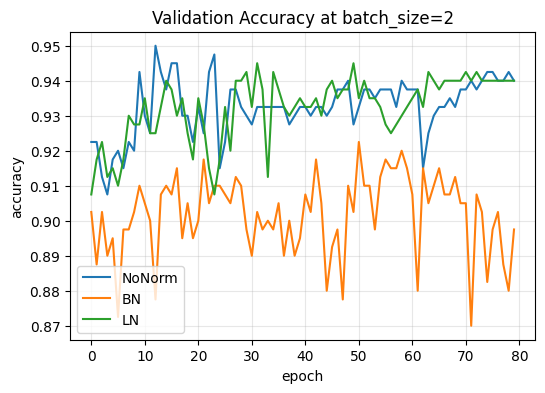

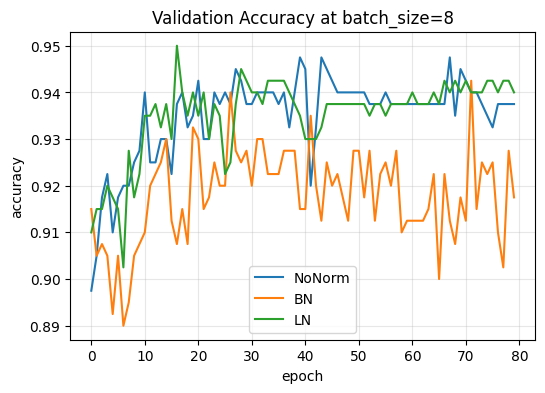

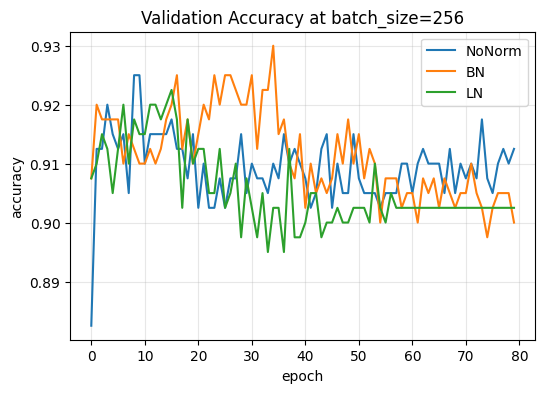

In [20]:
for bs in [2, 8, 256]:
    curves = {}
    for norm_name in ["NoNorm", "BN", "LN"]:
        key = f"{norm_name}-bs{bs}"
        curves[norm_name] = small_batch_norm_results[key]["val_acc"]

    plot_curves(
        curves,
        title=f"Validation Accuracy at batch_size={bs}",
        xlabel="epoch",
        ylabel="accuracy"
    )

In [21]:
for bs in [2, 8, 256]:
    print(f"\n[batch_size={bs}]")
    for norm_name in ["NoNorm", "BN", "LN"]:
        key = f"{norm_name}-bs{bs}"
        final_train = small_batch_norm_results[key]["train_acc"][-1]
        final_val = small_batch_norm_results[key]["val_acc"][-1]
        final_test = small_batch_norm_results[key]["test_acc"][-1]
        print(f"{norm_name:6s} | final train acc: {final_train:.4f} | final val acc: {final_val:.4f} | final test acc: {final_test:.4f}")


[batch_size=2]
NoNorm | final train acc: 1.0000 | final val acc: 0.9400 | final test acc: 0.9300
BN     | final train acc: 0.7192 | final val acc: 0.8975 | final test acc: 0.9075
LN     | final train acc: 1.0000 | final val acc: 0.9400 | final test acc: 0.9275

[batch_size=8]
NoNorm | final train acc: 1.0000 | final val acc: 0.9375 | final test acc: 0.9425
BN     | final train acc: 0.9400 | final val acc: 0.9175 | final test acc: 0.9275
LN     | final train acc: 1.0000 | final val acc: 0.9400 | final test acc: 0.9250

[batch_size=256]
NoNorm | final train acc: 1.0000 | final val acc: 0.9125 | final test acc: 0.9125
BN     | final train acc: 1.0000 | final val acc: 0.9000 | final test acc: 0.9075
LN     | final train acc: 1.0000 | final val acc: 0.9025 | final test acc: 0.9150
